In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, Parameter
from qiskit.quantum_info import Statevector, Operator

from qiskit.circuit.library import QFT, QFTGate, UnitaryGate
# https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFTGate
# https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UnitaryGate

import matplotlib.pyplot as plt
import numpy as np
import math
from pprint import pprint

# Quantum Calculator

Submitted by: **Tom Alberts**

## Summary
This notebook is a step towards implementing a quantum calculator. The goal was a circuit that does the following: based on the value of a control gate it returns either the sum or the product of two $d$-ary numbers, each computed $\mod d$. 

More specifically, a function called $\text{QCalc}$ is supposed to input a positive integer $d$ and return a quantum circuit that operates on $3d + 1$ qubits via
$$
\text{QCalc} \lvert x \rangle_d \lvert y \rangle_d \lvert z \rangle_1 \lvert 0 \rangle_d = \begin{cases}
\lvert x \rangle_d \lvert y \rangle_d \lvert z \rangle_1 \lvert x + y \mod 2^d \rangle_d, & z = 0 \\
\lvert x \rangle_d \lvert y \rangle_d \lvert z \rangle_1 \lvert x \cdot y \mod 2^d \rangle_d, & z = 1 \\
\end{cases}
$$

Due to time constraints the addition and multiplication circuits are implemented separately in this notebook. For the addition case ($z = 0$) the function below is a straightforward implementation of <a href="#draper2000">Draper's addition algorithm</a>. For the multiplication case ($z = 1$) the function modifies Draper's algorithm by adding an extra for loop. This extra for loop accounts for the [Cauchy product](https://en.wikipedia.org/wiki/Cauchy_product) that occurs in the product of two numbers given by their binary represenation, i.e.

$$
\left( \sum_{i=0}^{\infty} a_i 2^i \right) \left( \sum_{i=0}^{\infty} b_i 2^i \right) = \sum_{\ell=0}^{\infty} \left( \sum_{j=0}^{\ell} a_j b_{\ell-j} \right) 2^{\ell}
$$

## Introductory Notes

### Note on Binary Convention

In verifying the methods, the convention is that in the binary string representation the **leftmost bit is the most significant**. More precisely

$$
x_{n-1} x_{n-2} \ldots x_1 x_0 \textrm{ represents } \sum_{i=0}^{n-1} x_i 2^i
$$

A very frustrating part of implementing this notebook was sorting out the convention used in notes and textbooks versus the convention used in Qiskit. And just remembering how Python ordering of arrays works. I imagine that is par for the course in this business.

### Note on Implementation

I implemented separate functions for addition ($\text{QAdd}$) and multiplication ($\text{QMultiply}$). I ran out of time (and energy) to convert them into a single function that implements different rules according to the $z$ bit. It should not be difficult to combine them into one by making use of some NOT gates, and adding the $z$ bit as one of the conditional bits in the 'mcp' gates.

### Contents

The remaining subsections containt he following, in this order:
- **Implementation**: has the implementation of $\text{QAdd}$ and $\text{QMultiply}$.
- **Verification**: implements code that runs the methods against all possible inputs and checks that they produce the correct output. Also checks that the output is always deterministic (up to some negligible error).
- **Analysis**: counts the number of resources used asymptotically.
- **Discussion**: lists some ways that the code and implementation could be improved. 

## Implementation

The implemented methods use [ancilla bits](https://en.wikipedia.org/wiki/Ancilla_bit), [single qubit gates](https://qtank.github.io/QuantumLearn/Tutorial/quantumCircuit/one_qubit_gate.html), [CX gates](https://cnot.io/quantum_computing/two_qubit_operations.html), and [Toffoli gates](https://en.wikipedia.org/wiki/Toffoli_gate). The multiplication algorithm uses [multi-controlled phase gates](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.MCPhaseGate) and the [mcp()](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit) method.

The methods also make use of the [Quantum Fourier Transform](https://en.wikipedia.org/wiki/Quantum_Fourier_transform) and its inverse. The version used here makes use of swap gates so that the bitwise ordering matches the convention above. The implementation of the QFT and its inverse is the same as used in the problem session. Essentially the same implementation is already present in the [Qiskit QFT circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.QFT). 

### QFT and Inverse QFT implementation

In [2]:
def quantum_fourier_transform(n):
    quantum_register = QuantumRegister(size=n, name="x")
    QFT_circuit = QuantumCircuit(quantum_register, name=f"QFT")

    for q, p in zip(quantum_register[:n >> 1], reversed(quantum_register[n >> 1:])):
        QFT_circuit.swap(q, p)

    for i, q in enumerate(quantum_register, start=1):
        QFT_circuit.h(q)
        for j, p in enumerate(quantum_register[i:], start=1):
            QFT_circuit.cp(np.pi / (1 << j), q, p)

    return QFT_circuit

def inverse_quantum_fourier_transform(n):
    quantum_register = QuantumRegister(size=n, name="x")
    inverse_QFT_circuit = QuantumCircuit(quantum_register, name=f"IQFT")

    for i, q in enumerate(reversed(quantum_register), start=1):
        for j, p in enumerate(reversed(quantum_register[n + 1 - i:]), start=1):
            inverse_QFT_circuit.cp(- np.pi / (1 << (i - j)), q, p)
        inverse_QFT_circuit.h(q)

    for q, p in zip(quantum_register[:n >> 1], reversed(quantum_register[n >> 1:])):
        inverse_QFT_circuit.swap(q, p)

    return inverse_QFT_circuit

### QAdd implementation

This section implements a function $\text{QAdd}$ that takes a positive integer $d$ and returns a circuit that operates on $3d$ qubits via
$$
\text{QAdd} \lvert x \rangle_d \lvert y \rangle_d \lvert 0 \rangle_d =  \lvert x \rangle_d \lvert y \rangle_d \lvert x + y \mod 2^d \rangle_d
$$

In [3]:
def QAdd(d):

    # create three registers and join them together into a circuit
    quantum_register_input_1 = QuantumRegister(d, name='x')
    quantum_register_input_2 = QuantumRegister(d, name='y')
    quantum_register_output = QuantumRegister(d, name='o')
    qadd = QuantumCircuit(quantum_register_input_1, quantum_register_input_2, quantum_register_output, name="quantum adder")

    # copy the y bits to the o bits via CNOT gates
    for i in range(d):
       qadd.cx(quantum_register_input_2[i], quantum_register_output[i])

    # decorative barrier between the copy operation and the QFT operation
    qadd.barrier()
    
    # immediately apply the QFT to the output bits - note that this implementation uses swaps
    qadd.append(quantum_fourier_transform(d).to_gate(), quantum_register_output)
    
    # decorative barrier between QFT part and adder part
    qadd.barrier()

    # do swaps on the x bits to change order of signficance, matching what was done with the QFT
    for q, p in zip(quantum_register_input_1[:d >> 1], reversed(quantum_register_input_1[d >> 1:])):
        qadd.swap(q, p)
    
    # perform the Draper addition states with controlled phase gates
    for i, q in enumerate(quantum_register_output, start=0):
        for j, p in enumerate(quantum_register_input_1[i:], start=0):
            qadd.cp(np.pi / (1 << j), p, q)

    # undo the swaps on the x bits
    for q, p in zip(quantum_register_input_1[:d >> 1], reversed(quantum_register_input_1[d >> 1:])):
        qadd.swap(q, p)
    
    # decorative barrier between barrier part and inverse quantum Fourier transform part    
    qadd.barrier()
    
    # undo the QFT on the output bits
    qadd.append(inverse_quantum_fourier_transform(d).to_gate(), quantum_register_output)
        
    # return the circuit
    return qadd

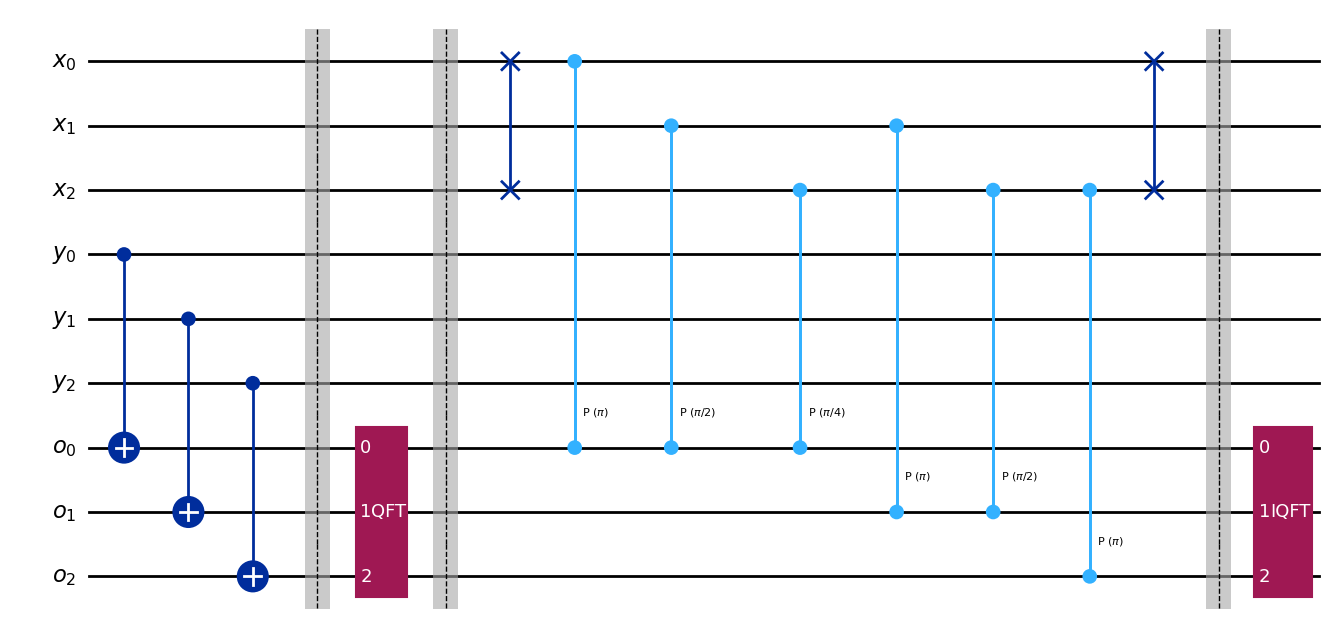

In [4]:
# An image of the QAdd circuit for d = 3
QAdd(3).draw(output="mpl")

#### QAdd Notes

The part in the middle, between the QFT and the Inverse QFT, is essentially <a href="#draper2000">Draper's addition algorithm</a>. This sequence of controlled phase gates adds the $x$ bits onto the $y$ bits in Fourier space. As Draper notes, and as the diagram shows, this operations in this middle part all commute with each other.

### QMultiply implementation

This section implements a function $\text{QMultiply}$ that takes a positive integer $d$ and returns a circuit that operates on $3d$ qubits via
$$
\text{QMultiply} \lvert x \rangle_d \lvert y \rangle_d \lvert 0 \rangle_d =  \lvert x \rangle_d \lvert y \rangle_d \lvert x \cdot y \mod 2^d \rangle_d
$$

In [5]:
def QMultiply(d):
    # create three registers and join them together into a circuit
    quantum_register_input_1 = QuantumRegister(d, name='x')
    quantum_register_input_2 = QuantumRegister(d, name='y')
    quantum_register_output = QuantumRegister(d, name='o')
    qm = QuantumCircuit(quantum_register_input_1, quantum_register_input_2, quantum_register_output, name="quantum multiplier")

    # apply the QFT to the o bits
    qm.append(quantum_fourier_transform(d).to_gate(), quantum_register_output)

    # decorative barrier
    qm.barrier()
    
    # do the Cauchy summation formula for the product of x*y, to mimic the Draper addition
    for k, r in enumerate(quantum_register_output, start=0):
        for ell in range(k+1):
            for j in range(ell+1):
                qm.mcp(np.pi/(1 << (k-ell)), [quantum_register_input_1[j], quantum_register_input_2[ell-j]], quantum_register_output[d-1-k])

    # decorative barrier between barrier part and inverse quantum Fourier transform part    
    qm.barrier()
    
    # undo the QFT on the o bits
    qm.append(inverse_quantum_fourier_transform(d).to_gate(), quantum_register_output)
        
    # return the circuit
    return qm

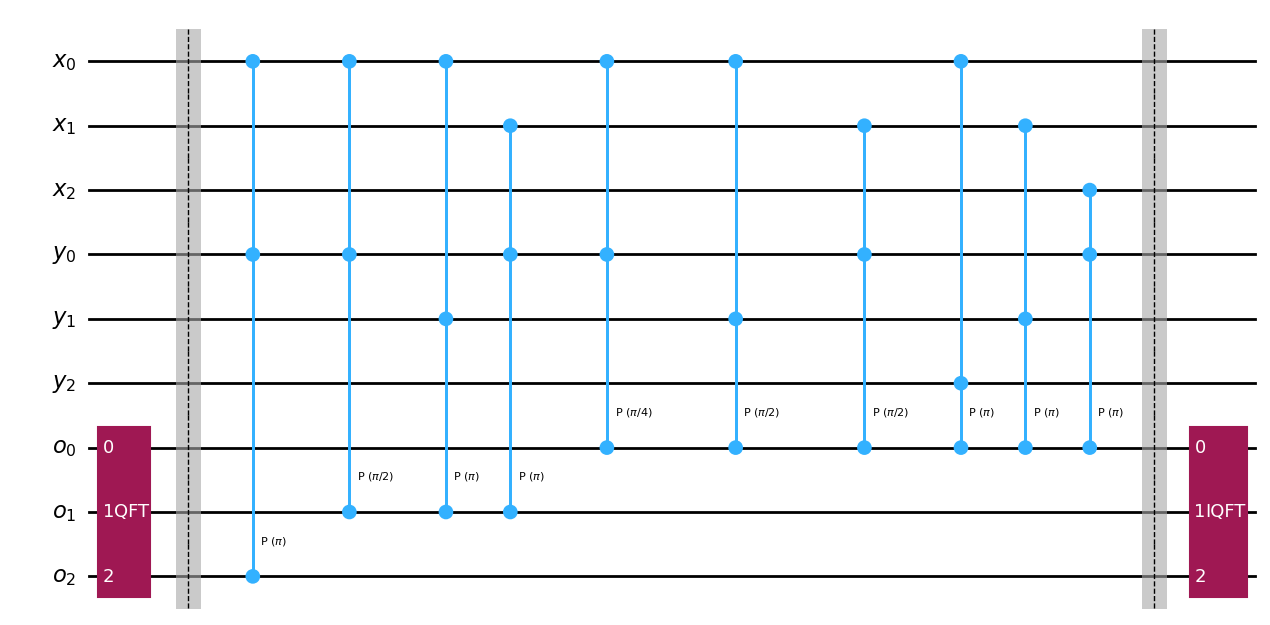

In [6]:
# An image of the QMultiply circuit for d = 3
QMultiply(3).draw(output="mpl")

#### QMultiply notes

The blue part in the middle is the implementation of the Cauchy summation formula. Instead of applying a controlled phase if only a particular $x$ bit is equal to $1$, it applies a controlled phase if both an $x$ *and* a $y$ bit are **both** 1. The many combinations of $x$ and $y$ bits that show up in the controls are all the terms in the Cauchy summation formula. Indeed, by writing
$$
x = \sum_{i=0}^{\infty} x_i 2^i, \quad y = \sum_{i=0}^{\infty} y_i 2^i,
$$
with $x_k = y_k = 0$ for $k \geq d$, the Cauchy summation formula tells us that
$$
x \cdot y \mod 2^d = \sum_{\ell=0}^{d-1} \sum_{k=0}^{\ell} x_{k} y_{\ell-k} 2^{\ell}.
$$
The implementation of $\text{QMultiply}$ combines this formula with Draper's idea. It adds the terms above in Fourier space (in this case it adds them all to the initial value of zero) via a sequence of **multi**-controlled phase gates. The index $\ell$ determines the appropriate phase for each gate.

## Verification

The method below verifies the correctness of these circuits via exhaustion. Given an input value of $d$, it inputs all pairs $(x, y) \in \{0,1 \}^d \times \{0,1 \}^d$ into the circuit and checks that:
- the output is deterministic (up to a tolerance of $10^{-9}$), and
- the output matches the expected value, as computed by the classical computer.

The method returns a pair of dictionaries '(summary, results)'. The *summary* dictionary lists the number of deterministic circuits outputs and, separately, the number of circuit outputs that match the expected value. The *results* dictionary lists all inputs and the full result of the test for that particular input.

This method should only be used for small values of $d$ (up to say $d = 8$) since the input size is $2^{2d}$.

In [7]:
# Verify the correctness of the QAdd and QMultiply routines by checking all possible inputs against the correct output
# Should only be used for small values of d, say d <= 8, since input size is 2^(2d)

# Set method_to_test flag to either "add" or "multiply"

def verify(d, method_to_test="add"):

    size = 1 << d
    TestCircuit = QMultiply(d) if method_to_test == "multiply" else QAdd(d)
    
    results = []
    numDeterministic = 0
    numMatchingExpected = 0
    
    for k in range(size*size):
        i = k >> d
        j = k & ((1 << d) - 1)

        result = dict()

        # input str, padded with the correct number of zeros
        # note the order is reversed compared to 'input decimal' because of Qiskit ordering
        input_str = '0'*d + f"{j:0{d}b}{i:0{d}b}" 
        
        result["input"] = input_str
        result["input decimal"] = f"(x={i}, y={j}, target=0)"

        # compute the correct value
        # note the order of 'expected_state_ is reversed compared to 'expected decimal' because of Qiskit ordering
        expected = (i * j) % (size) if method_to_test == "multiply" else (i + j) % size
        
        expected_state = f"{expected:0{d}b}{j:0{d}b}{i:0{d}b}"
        result["expected"] = expected_state
        result["expected decimal"] = f"(x={i}, y={j}, target={expected})"
        
        initial_state = Statevector.from_label(input_str)
        final_state = initial_state.evolve(TestCircuit)

        probs = final_state.probabilities_dict()
        detected_state, max_probability = max(probs.items(), key=lambda item: item[1])
        result["highest prob state"] = detected_state

        # We expect deterministic output so check that only ONE state exists in the output
        if math.isclose(max_probability, 1.0, rel_tol=1e-9):
            result["deterministic"] = f"✅"
            numDeterministic += 1
        else:
            result["deterministic"] = f"❌"

        # check that the highest probability state matches what is expected
        if (detected_state == expected_state):
            result["highest prob state matches expected"] = f"✅"
            numMatchingExpected += 1
        else:
            result["highest prob state matches expected"] = f"❌"

        results.append(result)

    summary = dict()
    summary["Deterministic"] = f"{numDeterministic} / {size*size}"
    summary["Match Expected"] = f"{numMatchingExpected} / {size*size}"

    return (summary, results)

### Verify QAdd

First we use the method to verify QAdd for various values of $d$. We only check that all results are deterministic and match the expected value.

In [8]:
# d=2
(summary, results) = verify(2, "add")
print(summary)

{'Deterministic': '16 / 16', 'Match Expected': '16 / 16'}


In [9]:
# results for d=2
for result in results:
    pprint(result)

{'deterministic': '✅',
 'expected': '000000',
 'expected decimal': '(x=0, y=0, target=0)',
 'highest prob state': np.str_('000000'),
 'highest prob state matches expected': '✅',
 'input': '000000',
 'input decimal': '(x=0, y=0, target=0)'}
{'deterministic': '✅',
 'expected': '010100',
 'expected decimal': '(x=0, y=1, target=1)',
 'highest prob state': np.str_('010100'),
 'highest prob state matches expected': '✅',
 'input': '000100',
 'input decimal': '(x=0, y=1, target=0)'}
{'deterministic': '✅',
 'expected': '101000',
 'expected decimal': '(x=0, y=2, target=2)',
 'highest prob state': np.str_('101000'),
 'highest prob state matches expected': '✅',
 'input': '001000',
 'input decimal': '(x=0, y=2, target=0)'}
{'deterministic': '✅',
 'expected': '111100',
 'expected decimal': '(x=0, y=3, target=3)',
 'highest prob state': np.str_('111100'),
 'highest prob state matches expected': '✅',
 'input': '001100',
 'input decimal': '(x=0, y=3, target=0)'}
{'deterministic': '✅',
 'expected': '010

In [10]:
# d=3
(summary, results) = verify(3, "add")
print(summary)

{'Deterministic': '64 / 64', 'Match Expected': '64 / 64'}


In [11]:
# d=5
(summary, results) = verify(5, "add")
print(summary)

{'Deterministic': '1024 / 1024', 'Match Expected': '1024 / 1024'}


### Verify QMultiply

In [12]:
# d=2
(summary, results) = verify(2, "multiply")
print(summary)

{'Deterministic': '16 / 16', 'Match Expected': '16 / 16'}


In [13]:
# results for d=2
for result in results:
    pprint(result)

{'deterministic': '✅',
 'expected': '000000',
 'expected decimal': '(x=0, y=0, target=0)',
 'highest prob state': np.str_('000000'),
 'highest prob state matches expected': '✅',
 'input': '000000',
 'input decimal': '(x=0, y=0, target=0)'}
{'deterministic': '✅',
 'expected': '000100',
 'expected decimal': '(x=0, y=1, target=0)',
 'highest prob state': np.str_('000100'),
 'highest prob state matches expected': '✅',
 'input': '000100',
 'input decimal': '(x=0, y=1, target=0)'}
{'deterministic': '✅',
 'expected': '001000',
 'expected decimal': '(x=0, y=2, target=0)',
 'highest prob state': np.str_('001000'),
 'highest prob state matches expected': '✅',
 'input': '001000',
 'input decimal': '(x=0, y=2, target=0)'}
{'deterministic': '✅',
 'expected': '001100',
 'expected decimal': '(x=0, y=3, target=0)',
 'highest prob state': np.str_('001100'),
 'highest prob state matches expected': '✅',
 'input': '001100',
 'input decimal': '(x=0, y=3, target=0)'}
{'deterministic': '✅',
 'expected': '000

In [14]:
# d=3
(summary, results) = verify(3, "multiply")
print(summary)

{'Deterministic': '64 / 64', 'Match Expected': '64 / 64'}


In [15]:
# d=5
(summary, results) = verify(5, "multiply")
print(summary)

{'Deterministic': '1024 / 1024', 'Match Expected': '1024 / 1024'}


## Analysis

Since the addition and multiplication methods were implemented separately we analyze them separately. If they are ultimately combined into a single $\text{QCalc}$ method, the combined method will likely follow either the additiona algorithm or the multiplication algorithm depending on the value of the $z$ bit. The algorithms themselves will likely not change, there will just be more ancillas in the overall circuit.

### Analysis of QAdd

There are probably some simplifications and improvements that can be made to my implementation of $\text{QAdd}$. I spent a long time working through the basics of Qiskit operations while implementing it, and so was not focused on optimizing. In the asymptotic sense I believe my implementation is essentially optimal.

#### Gate Count
As implemented the $\text{QAdd}$ operation requires
- $d$ copy gates from an input register to the output register
- the QFT, which requires $O(d^2)$ gates
- Draper's addition step, which is defined via a double for loop, and therefore requires $O(d^2)$ controlled phase gates
- the inverse QFT, which requires another $O(d^2)$ gates

Note that I did not include swaps in the analysis above, largely because I included swaps only for my own ease of use. They are not strictly necessary as long as the bit ordering is adjusted correspondingly. 

However, regardless of whether or not swaps are included the asymptotic gate count is $O(d^2)$

#### Gate Depth

One of the advantages of Draper's addition algorithm is that it can be effectively parallelized. Many of the controlled phase gates can be executed at once. As Draper's paper shows, the number of time slices can be reduced to $O(\log_2 d)$.

The internet tells me that the gate depth of the QFT can be reduced to $O(d)$ with some well chosen parallelizations. This is going to be the biggest bottleneck, so the overall depth will be $O(d)$.

#### Ancillas

No ancillas are used in the addition algorithm, which is one of the reasons it is nicer than adders that do "carry" operations.

### Analysis of QMultiply

For the $\text{QMultiply}$ circuit the number of multi-controlled phase gates grows substantially faster, making it less efficient.

#### Gate Count
As implemented the $\text{QMultiply}$ operation uses
- the QFT, which requires $O(d^2)$ gates
- Draper's addition step based on Cauchy summation. This is defined via a triple for loop, and so requires $O(d^3)$ controlled phase gates.
- the inverse QFT, which requires another $O(d^2)$ gates

The asymptotic gate count will therefore be $O(d^3)$.

#### Gate Depth

The depth of the QFT can be reduced to $O(d)$ via parallelization. Similarly, the depth of the middle Draper step can be reduced to $O(d^2)$ by parallelization. This is done by stacking non-overlapping pairs of qubits. It should be possible to find $O(d)$ such pairs at a given time (see the note on parallelization below), which is what reduces from the gate count of $O(d^3)$ to the gate depth of $O(d^2)$.

The asymptotic gate depth is therefore $O(d^2)$.

#### Ancillas

No ancillas are used in the multiplication algorithm either. The original input bits are all that are needed to determine the controls for the multi-controlled phase gates.

## Discussion

### Modifications to QAdd

As currently implemented, QAdd copies one of the two input strings to the output register and then applies the QFT to that output register. This two step procedure initializes the value of the output register to be the QFT of one of the input registers. From there Draper's additional algorithm is performed.

Alternatively, one could perform Draper's addition algorithm twice. First apply the QFT to the output register, which is initialized to be all zeros. This is the same as applying the Hadamard transform. Then perform addition from input register 1 to the output register via Draper's algorithm, and finally perform addition from input register 2 to the output register using Draper again. Finally, apply the inverse QFT to the output register.

In the end these two methods are somewhat equivalent, but the second method has no copy operations and is therefore somewhat more elegant.

### Parallelization

As noted in the <a href="#draper2000">original quantum addition paper by Draper</a>, the quantum addition algorithm involves a sequence of commuting operations and therefore can be effectively parallelized. A quantum computer that can perform about $n$ independent $2$-qubit gate operations simultaneously can reduce the time complexity of the algorithm by a factor of $n$. 

## References

<a id="draper2000"></a>
* **Draper, T. (2000).** *Addition on a Quantum Computer.* arXiv:quant-ph/0008033. doi: [10.48550/arXiv.quant-ph/0008033](https://doi.org/10.48550/arXiv.quant-ph/0008033)